In [44]:
# Regular EDA and plotting libraries
import numpy as np  #tableaux et matrices
import pandas as pd # Permet de manipuler et d'analyser des données sous forme de dataframes, ce qui est similaire à des tableaux Excel
import matplotlib.pyplot as plt  #Permet de créer des visualisations de données, comme des graphiques et des diagrammes.
import seaborn as sns #  Permet de créer des visualisations de données plus complexes et plus attrayantes que celles fournies par matplotlib.

# We want our plots to appear in the notebook
# Afin de visualiser les graphiques dans le notebook
%matplotlib inline 


# Importation des métriques
from sklearn.metrics import accuracy_score


## Models
from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier

## Model evaluators
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict #utilisés pour diviser les données en ensembles d'entraînement et de test, et pour évaluer les modèles à l'aide de la validation croisée.
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV #pour ajuster les hyperparamètres des modèles.
from sklearn.metrics import confusion_matrix, classification_report # pour évaluer les performances des modèles de classification.
from sklearn.metrics import precision_score, recall_score, f1_score #pour évaluer les performances des modèles de classification.
from sklearn.metrics import RocCurveDisplay # new in Scikit-Learn 1.2+( utilisez une version antérieure de Scikit-Learn) #utilisé pour afficher la courbe ROC des modèles de classification.
from sklearn.metrics import roc_curve, roc_auc_score
# Print last updated
import time
print(f"Last updated: {time.asctime()}")

Last updated: Sat Apr 11 12:23:46 2026


In [45]:
df = pd.read_csv("heart_disease_dataset1.csv") # 'DataFrame' shortened to 'df'  # charger le jeu de données 
df.shape # (rows, columns)  # afficher sa taille

(1000, 16)

In [46]:
# Everything except target variable
X = df.drop("target", axis=1) #supprimer la variable target d'un dataframe et mettre le resultet dans X

# Target variable
y = df.target.values #pour obtenir les valeurs de la variable target dans Y

In [47]:
# Independent variables (no target column)
X.head()  #afficher les 5 premiers ligne de dataset sans target

,age,gender,chol,bp,hr,smoke,alcohol,exercise,family_hist,diabetes,obesity,stress,sugar,angina,cp
0,75,0,228,119,66,2,2.0,1,0,0,1,8,119,1,1
1,48,1,204,165,62,2,0.0,5,0,0,0,9,70,1,0
2,53,1,234,91,67,0,2.0,3,1,0,1,5,196,1,1
3,69,0,192,90,72,2,0.0,4,0,1,0,7,107,1,2
4,62,0,172,163,93,0,0.0,6,0,1,0,2,183,1,3


In [48]:
# Random seed for reproducibility
np.random.seed(42)

# Split into train & test set
X_train, X_test, y_train, y_test = train_test_split(X, # independent variables 
                                                    y, # dependent variable
                                                    test_size = 0.2,
                                                    random_state=42,
                                                    shuffle=True
                                                   ) # percentage of data to use for test set

# diviser un ensemble de données en un ensemble d'entraînement et un ensemble de test

In [49]:
X_train.head()  #afficher les 5 premières lignes du DataFrame X_train

,age,gender,chol,bp,hr,smoke,alcohol,exercise,family_hist,diabetes,obesity,stress,sugar,angina,cp
29,79,1,319,115,63,0,1.0,0,1,0,1,9,95,0,0
535,38,0,340,176,98,2,2.0,5,0,0,0,1,155,1,2
695,62,1,213,141,93,2,1.0,2,0,1,0,6,158,1,2
557,34,1,338,104,83,0,2.0,9,1,1,1,7,105,0,2
836,57,0,185,126,94,0,1.0,1,0,1,0,5,106,0,0


In [50]:
# Définissez les modèles
models = {"KNN": KNeighborsClassifier(weights="distance",n_neighbors=15,algorithm="auto"),
          "Logistic Regression": LogisticRegression(C=4.281332398719396,solver="liblinear"), 
          "Random Forest": RandomForestClassifier(n_estimators= 510, min_samples_split= 18, min_samples_leaf= 19, max_depth= 5),
          "SVM": SVC(kernel='poly',C=100, probability=True),
          "Decision Tree": DecisionTreeClassifier(min_samples_split=18, min_samples_leaf=9, max_depth=5),
          "AdaBoost": AdaBoostClassifier(n_estimators=50, learning_rate=0.1),
          "GradientBoosting": GradientBoostingClassifier(n_estimators= 50,min_samples_split= 10,min_samples_leaf= 4,max_depth= 3,learning_rate= 0.01),
          "GaussianNB": GaussianNB(),
         "ExtraTrees": ExtraTreesClassifier(n_estimators=700, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', max_depth=80, bootstrap=False)}

def get_metrics(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # gestion automatique proba
    if hasattr(model, "predict_proba"):
        y_train_prob = model.predict_proba(X_train)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_train_prob = model.decision_function(X_train)
        y_test_prob = model.decision_function(X_test)

    return {
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "train_precision": precision_score(y_train, y_train_pred),
        "train_recall": recall_score(y_train, y_train_pred),
        "train_f1": f1_score(y_train, y_train_pred),
        "train_auc": roc_auc_score(y_train, y_train_prob),

        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_precision": precision_score(y_test, y_test_pred),
        "test_recall": recall_score(y_test, y_test_pred),
        "test_f1": f1_score(y_test, y_test_pred),
        "test_auc": roc_auc_score(y_test, y_test_prob)
    }

results = []

for name, model in models.items():
    print(f"Training {name} ...")
    
    metrics = get_metrics(model, X_train, X_test, y_train, y_test)
    metrics["Model"] = name
    results.append(metrics)

df_results = pd.DataFrame(results)

df_results

print("-----------------------------------")

Training KNN ...
Training Logistic Regression ...
Training Random Forest ...
Training SVM ...
Training Decision Tree ...
Training AdaBoost ...
Training GradientBoosting ...
Training GaussianNB ...
Training ExtraTrees ...
-----------------------------------


In [51]:
df_results[[
    "Model",

    # TRAIN
    "train_accuracy",
    "train_precision",
    "train_recall",
    "train_f1",
    "train_auc",

]].round(3)

,Model,train_accuracy,train_precision,train_recall,train_f1,train_auc
0,KNN,1.000,1.000,1.000,1.000,1.000
1,Logistic Regression,0.875,0.852,0.819,0.836,0.948
2,Random Forest,1.000,1.000,1.000,1.000,1.000
3,SVM,0.951,0.953,0.919,0.936,0.994
4,Decision Tree,1.000,1.000,1.000,1.000,1.000
5,AdaBoost,1.000,1.000,1.000,1.000,1.000
6,GradientBoosting,1.000,1.000,1.000,1.000,1.000
7,GaussianNB,0.909,0.934,0.823,0.875,0.978
8,ExtraTrees,1.000,1.000,1.000,1.000,1.000


In [52]:
df_results[[
    "Model",


    # TEST
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_auc"
]].round(3)

,Model,test_accuracy,test_precision,test_recall,test_f1,test_auc
0,KNN,0.915,0.892,0.902,0.897,0.978
1,Logistic Regression,0.865,0.840,0.829,0.834,0.948
2,Random Forest,1.000,1.000,1.000,1.000,1.000
3,SVM,0.960,0.962,0.939,0.951,0.994
4,Decision Tree,1.000,1.000,1.000,1.000,1.000
5,AdaBoost,1.000,1.000,1.000,1.000,1.000
6,GradientBoosting,1.000,1.000,1.000,1.000,1.000
7,GaussianNB,0.915,0.933,0.854,0.892,0.983
8,ExtraTrees,0.940,0.949,0.902,0.925,0.991


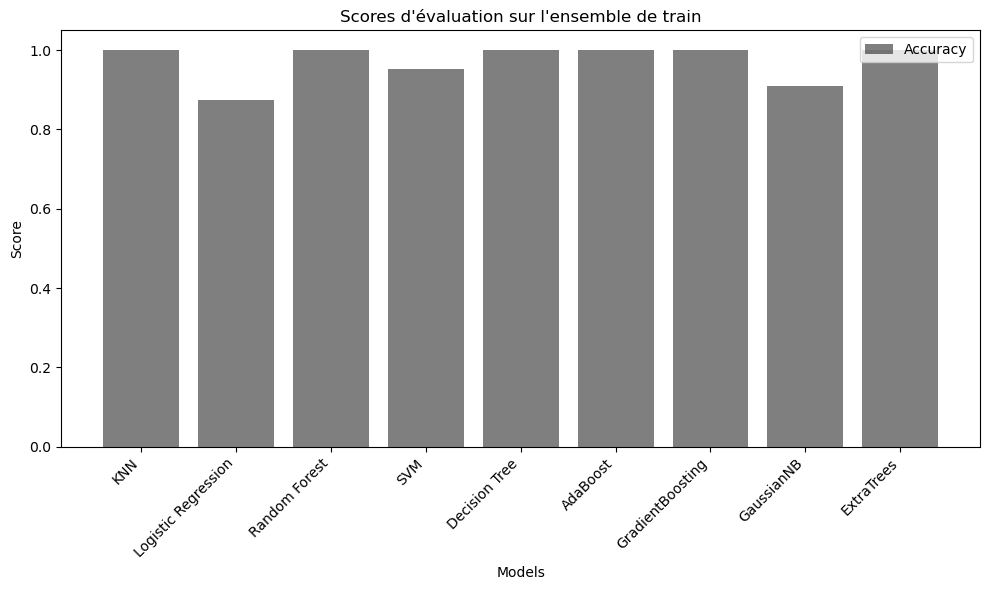

In [53]:
import matplotlib.pyplot as plt

model_names = df_results["Model"]
train_accuracy_scores = df_results["train_accuracy"]

plt.figure(figsize=(10,6))
plt.bar(model_names, train_accuracy_scores, color='black', alpha=0.5, label='Accuracy')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title("Scores d'évaluation sur l'ensemble de train")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

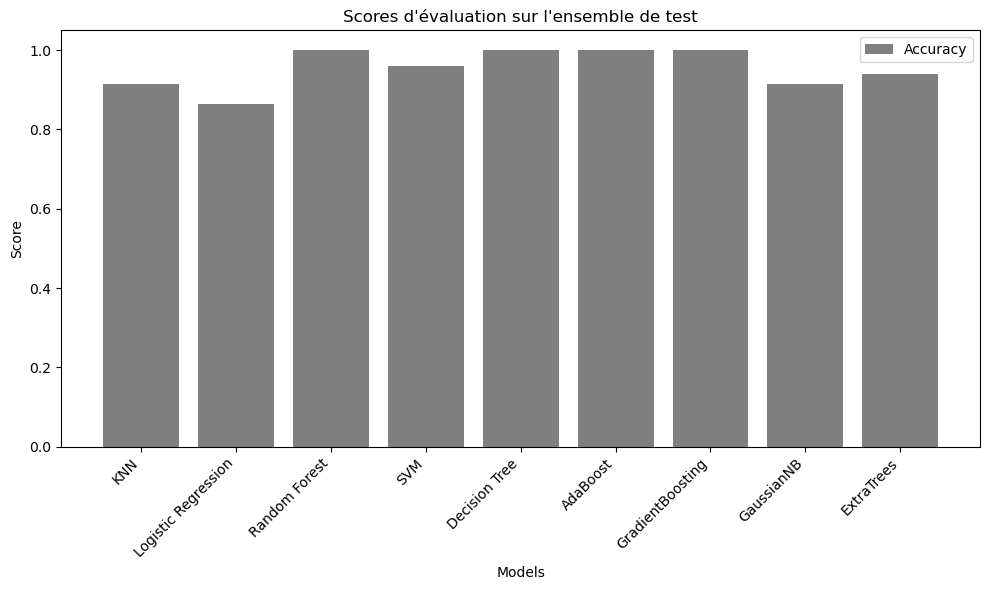

In [54]:
import matplotlib.pyplot as plt

model_names = df_results["Model"]
train_accuracy_scores = df_results["test_accuracy"]

plt.figure(figsize=(10,6))
plt.bar(model_names, train_accuracy_scores, color='black', alpha=0.5, label='Accuracy')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title("Scores d'évaluation sur l'ensemble de test")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

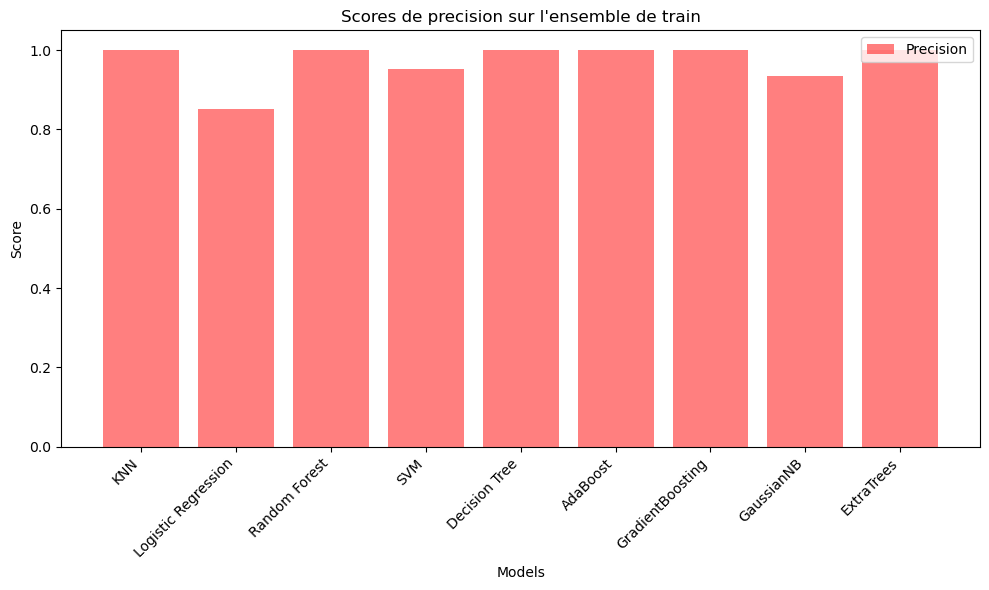

In [55]:
import matplotlib.pyplot as plt

model_names = df_results["Model"]
train_accuracy_scores = df_results["train_precision"]

plt.figure(figsize=(10,6))
plt.bar(model_names, train_accuracy_scores, color='r', alpha=0.5, label='Precision')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title("Scores de precision sur l'ensemble de train")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

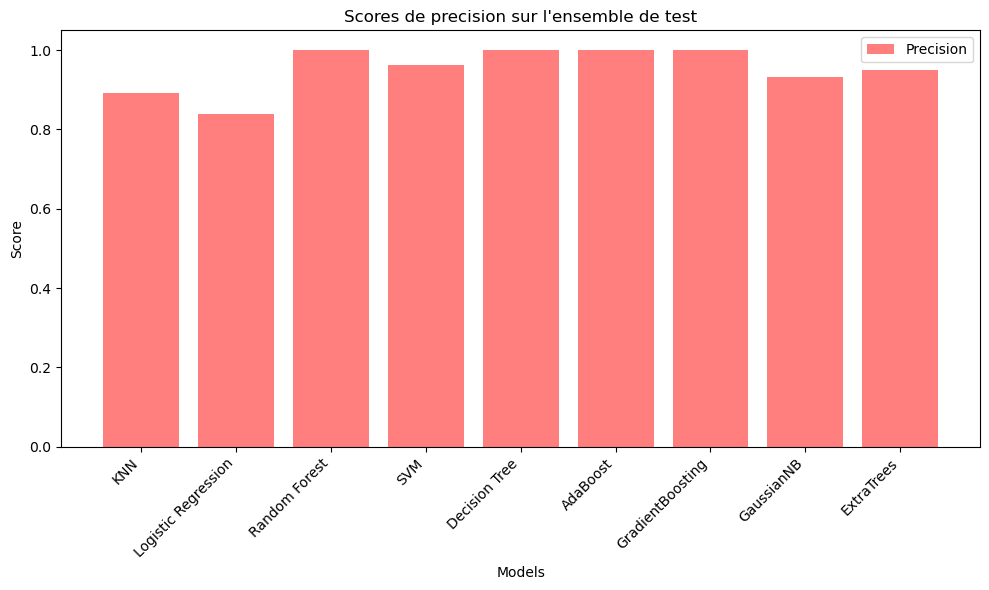

In [56]:
import matplotlib.pyplot as plt

model_names = df_results["Model"]
train_accuracy_scores = df_results["test_precision"]

plt.figure(figsize=(10,6))
plt.bar(model_names, train_accuracy_scores, color='r', alpha=0.5, label='Precision')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title("Scores de precision sur l'ensemble de test")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

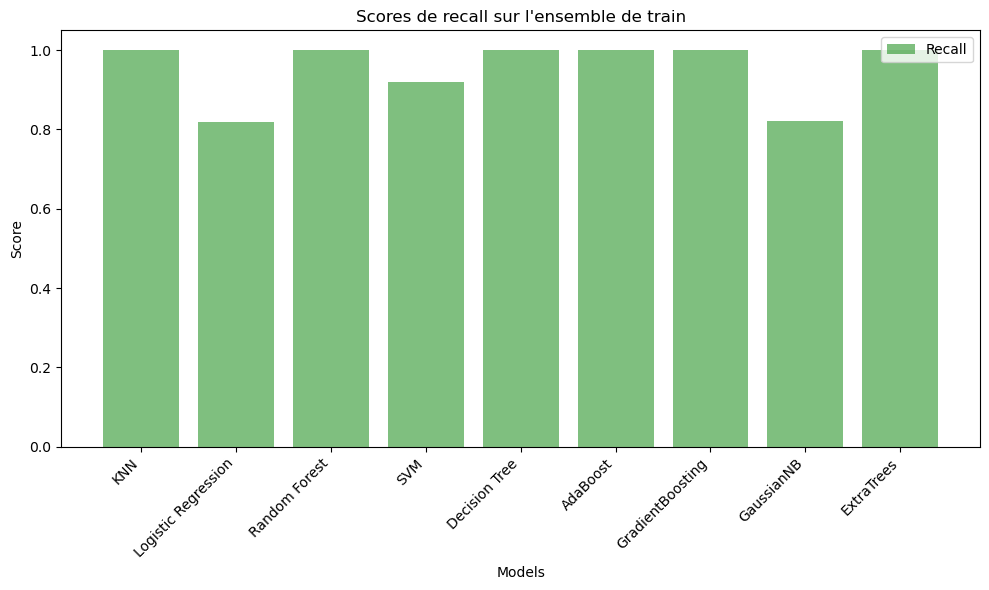

In [57]:
import matplotlib.pyplot as plt

model_names = df_results["Model"]
train_accuracy_scores = df_results["train_recall"]

plt.figure(figsize=(10,6))
plt.bar(model_names, train_accuracy_scores, color='g', alpha=0.5, label='Recall')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title("Scores de recall sur l'ensemble de train")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

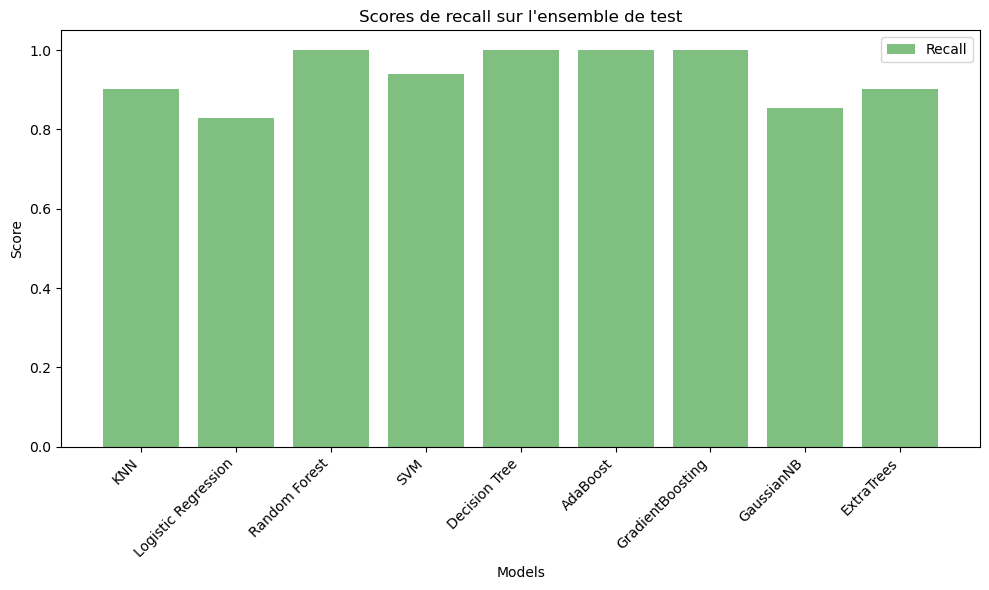

In [58]:
import matplotlib.pyplot as plt

model_names = df_results["Model"]
train_accuracy_scores = df_results["test_recall"]

plt.figure(figsize=(10,6))
plt.bar(model_names, train_accuracy_scores, color='g', alpha=0.5, label='Recall')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title("Scores de recall sur l'ensemble de test")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

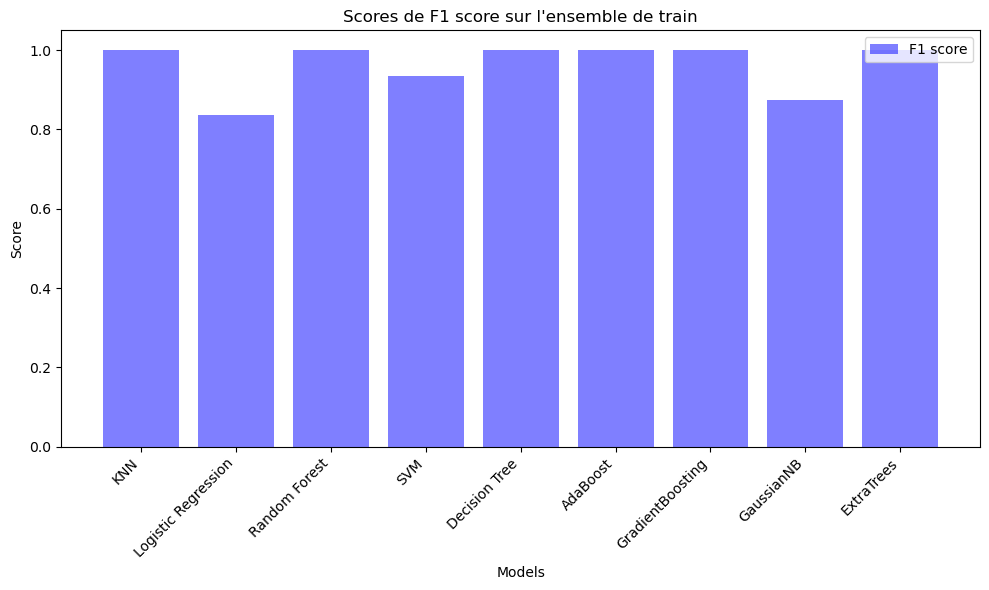

In [59]:
import matplotlib.pyplot as plt

model_names = df_results["Model"]
train_accuracy_scores = df_results["train_f1"]

plt.figure(figsize=(10,6))
plt.bar(model_names, train_accuracy_scores, color='b', alpha=0.5, label='F1 score')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title("Scores de F1 score sur l'ensemble de train")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

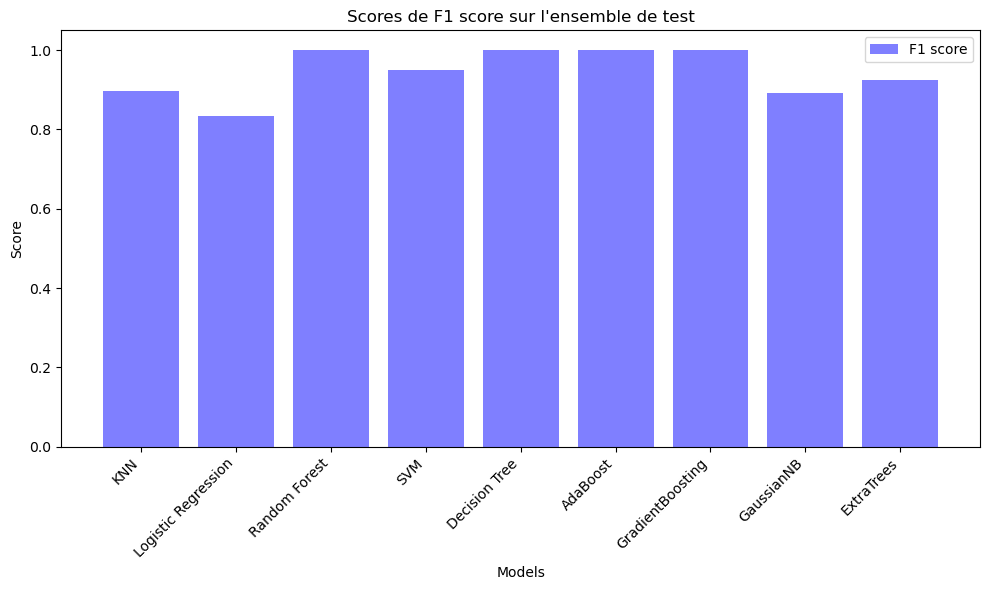

In [60]:
import matplotlib.pyplot as plt

model_names = df_results["Model"]
train_accuracy_scores = df_results["test_f1"]

plt.figure(figsize=(10,6))
plt.bar(model_names, train_accuracy_scores, color='b', alpha=0.5, label='F1 score')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title("Scores de F1 score sur l'ensemble de test")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

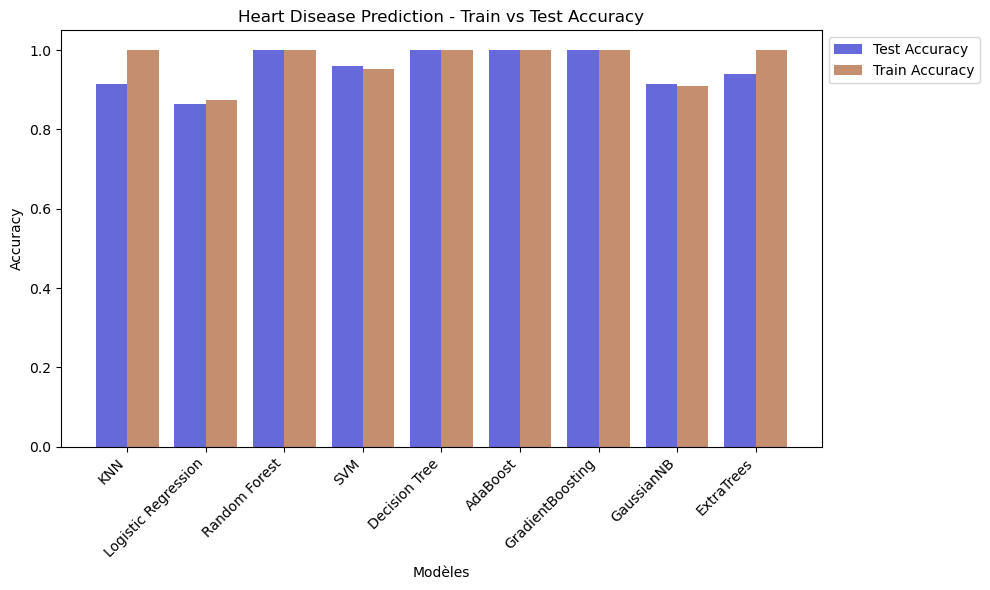

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Variables
model_names = df_results["Model"]
test_accuracy_scores = df_results["test_accuracy"]
train_accuracy_scores = df_results["train_accuracy"]

# Largeur des barres
bar_width = 0.4

# Position des barres
x = np.arange(len(model_names))

# Graphique
plt.figure(figsize=(10,6))

plt.bar(
    x - bar_width/2,
    test_accuracy_scores,
    bar_width,
    color='#0006c1',
    alpha=0.6,
    label='Test Accuracy'
)

plt.bar(
    x + bar_width/2,
    train_accuracy_scores,
    bar_width,
    color='#9f430e',
    alpha=0.6,
    label='Train Accuracy'
)

# Labels
plt.xlabel('Modèles')
plt.ylabel('Accuracy')
plt.title('Heart Disease Prediction - Train vs Test Accuracy')

plt.xticks(x, model_names, rotation=45, ha='right')

plt.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()

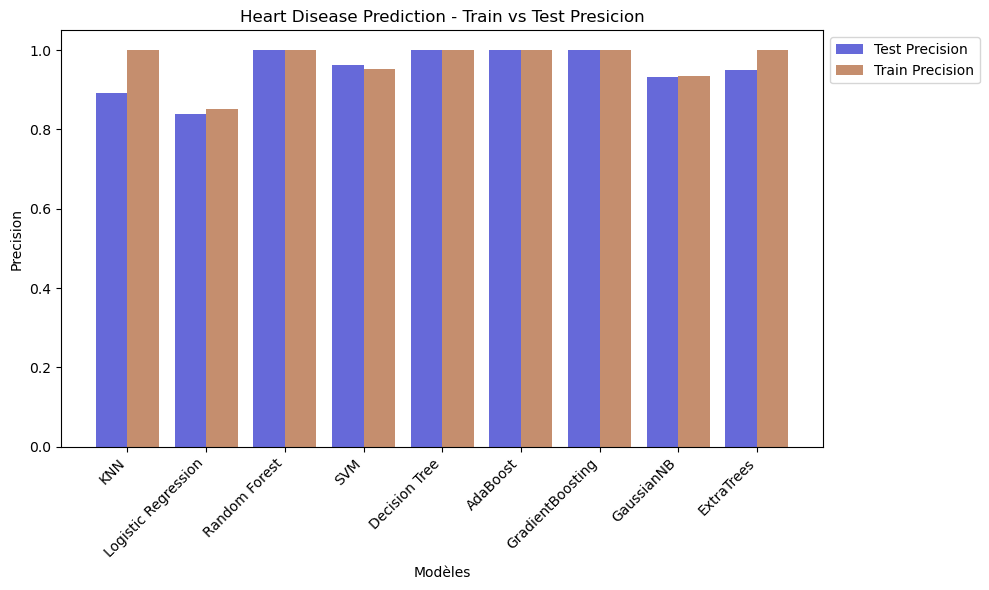

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# Variables
model_names = df_results["Model"]
test_accuracy_scores = df_results["test_precision"]
train_accuracy_scores = df_results["train_precision"]

# Largeur des barres
bar_width = 0.4

# Position des barres
x = np.arange(len(model_names))

# Graphique
plt.figure(figsize=(10,6))

plt.bar(
    x - bar_width/2,
    test_accuracy_scores,
    bar_width,
    color='#0006c1',
    alpha=0.6,
    label='Test Precision'
)

plt.bar(
    x + bar_width/2,
    train_accuracy_scores,
    bar_width,
    color='#9f430e',
    alpha=0.6,
    label='Train Precision'
)

# Labels
plt.xlabel('Modèles')
plt.ylabel('Precision')
plt.title('Heart Disease Prediction - Train vs Test Presicion')

plt.xticks(x, model_names, rotation=45, ha='right')

plt.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()

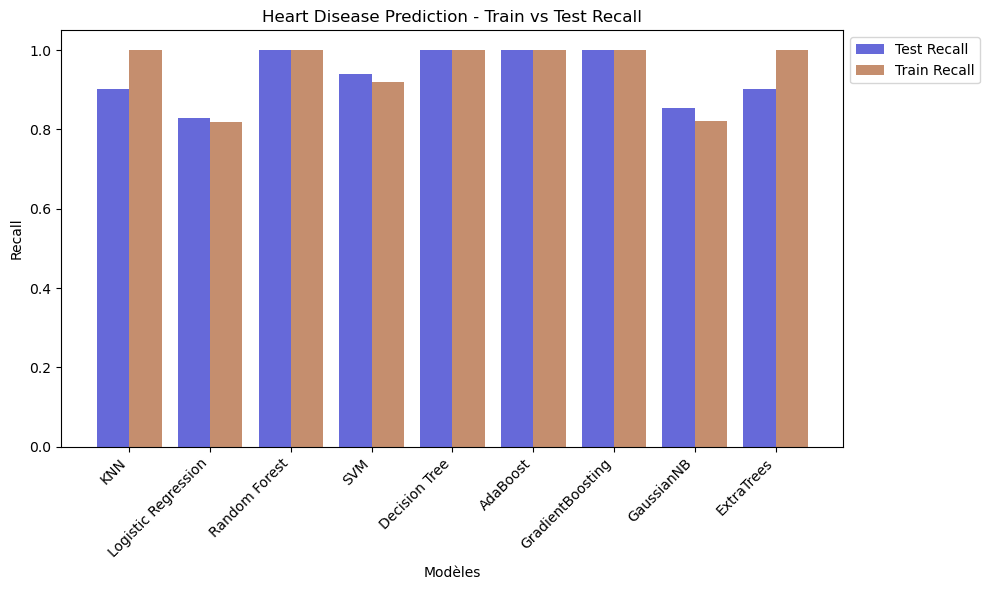

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Variables
model_names = df_results["Model"]
test_accuracy_scores = df_results["test_recall"]
train_accuracy_scores = df_results["train_recall"]

# Largeur des barres
bar_width = 0.4

# Position des barres
x = np.arange(len(model_names))

# Graphique
plt.figure(figsize=(10,6))

plt.bar(
    x - bar_width/2,
    test_accuracy_scores,
    bar_width,
    color='#0006c1',
    alpha=0.6,
    label='Test Recall'
)

plt.bar(
    x + bar_width/2,
    train_accuracy_scores,
    bar_width,
    color='#9f430e',
    alpha=0.6,
    label='Train Recall'
)

# Labels
plt.xlabel('Modèles')
plt.ylabel('Recall')
plt.title('Heart Disease Prediction - Train vs Test Recall')

plt.xticks(x, model_names, rotation=45, ha='right')

plt.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()

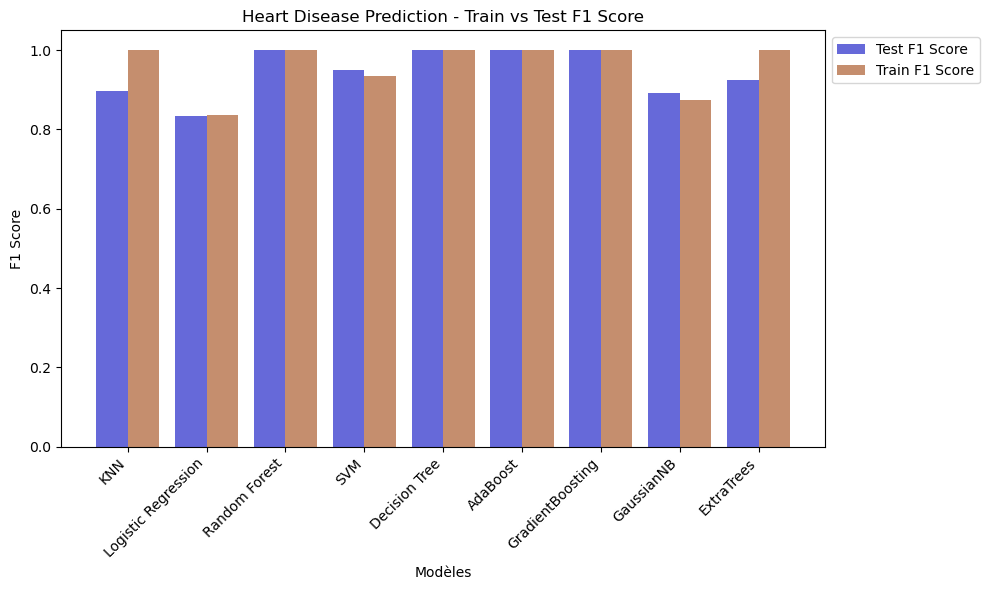

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Variables
model_names = df_results["Model"]
test_accuracy_scores = df_results["test_f1"]
train_accuracy_scores = df_results["train_f1"]

# Largeur des barres
bar_width = 0.4

# Position des barres
x = np.arange(len(model_names))

# Graphique
plt.figure(figsize=(10,6))

plt.bar(
    x - bar_width/2,
    test_accuracy_scores,
    bar_width,
    color='#0006c1',
    alpha=0.6,
    label='Test F1 Score'
)

plt.bar(
    x + bar_width/2,
    train_accuracy_scores,
    bar_width,
    color='#9f430e',
    alpha=0.6,
    label='Train F1 Score'
)

# Labels
plt.xlabel('Modèles')
plt.ylabel('F1 Score')
plt.title('Heart Disease Prediction - Train vs Test F1 Score')

plt.xticks(x, model_names, rotation=45, ha='right')

plt.legend(loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()

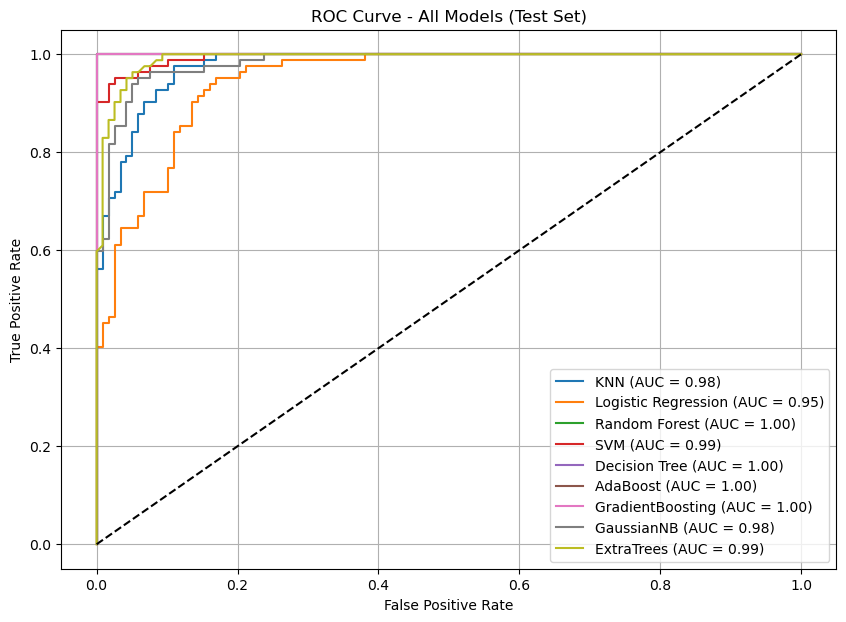

In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10,7))

for name, model in models.items():

    # prédiction des probabilités
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    # courbe
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

# ligne aléatoire
plt.plot([0, 1], [0, 1], "k--")

# style
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Models (Test Set)")
plt.legend(loc="lower right")

plt.grid()
plt.show()

In [66]:
print("Train F1 mean:", df_results["train_f1"].mean())
print("Test F1 mean:", df_results["test_f1"].mean())

Train F1 mean: 0.9606969442988004
Test F1 mean: 0.9442958393737891
